# PowerLens — 04. Dashboard Final & Rapport Visuel

> **KaynorData** · Descriptive Analytics · Energy Domain

---

## Objectif

Produire un **dashboard visuel complet** en une seule figure exportable :
- Synthèse des KPIs clés
- Meilleurs graphiques des notebooks précédents
- Format portfolio-ready (PNG haute résolution)


## 0. Imports & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

# Palette KaynorData
PRIMARY   = '#1a3c5e'
ACCENT    = '#2980b9'
SUCCESS   = '#27ae60'
WARNING   = '#e67e22'
DANGER    = '#e74c3c'
LIGHT_BG  = '#f8f9fa'

df = pd.read_parquet('../data/processed/powerlens_clean.parquet')
print(f'Dataset chargé : {df.shape[0]:,} lignes')

Dataset chargé : 2,075,259 lignes


## 1. Calcul des KPIs

In [2]:
total_kwh        = df['energy_kwh'].sum()
avg_daily_kwh    = df['energy_kwh'].resample('D').sum().mean()
avg_power        = df['Global_active_power'].mean()
peak_hour        = df.groupby('hour')['Global_active_power'].mean().idxmax()
peak_month       = df.groupby('month')['Global_active_power'].mean().idxmax()
month_names      = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
                    7:'Jul',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}

print(f'   KPIs PowerLens')
print(f'   Total consommé     : {total_kwh:,.0f} kWh')
print(f'   Moyenne journalière: {avg_daily_kwh:.2f} kWh/jour')
print(f'   Puissance moyenne  : {avg_power:.3f} kW')
print(f'   Heure de pointe    : {peak_hour}h')
print(f'   Mois le plus chargé: {month_names[peak_month]}')

   KPIs PowerLens
   Total consommé     : 37,710 kWh
   Moyenne journalière: 26.15 kWh/jour
   Puissance moyenne  : 1.090 kW
   Heure de pointe    : 20h
   Mois le plus chargé: Déc


## 2. Dashboard Final — Figure complète

Dashboard sauvegardé : reports/figures/04_powerlens_dashboard.png


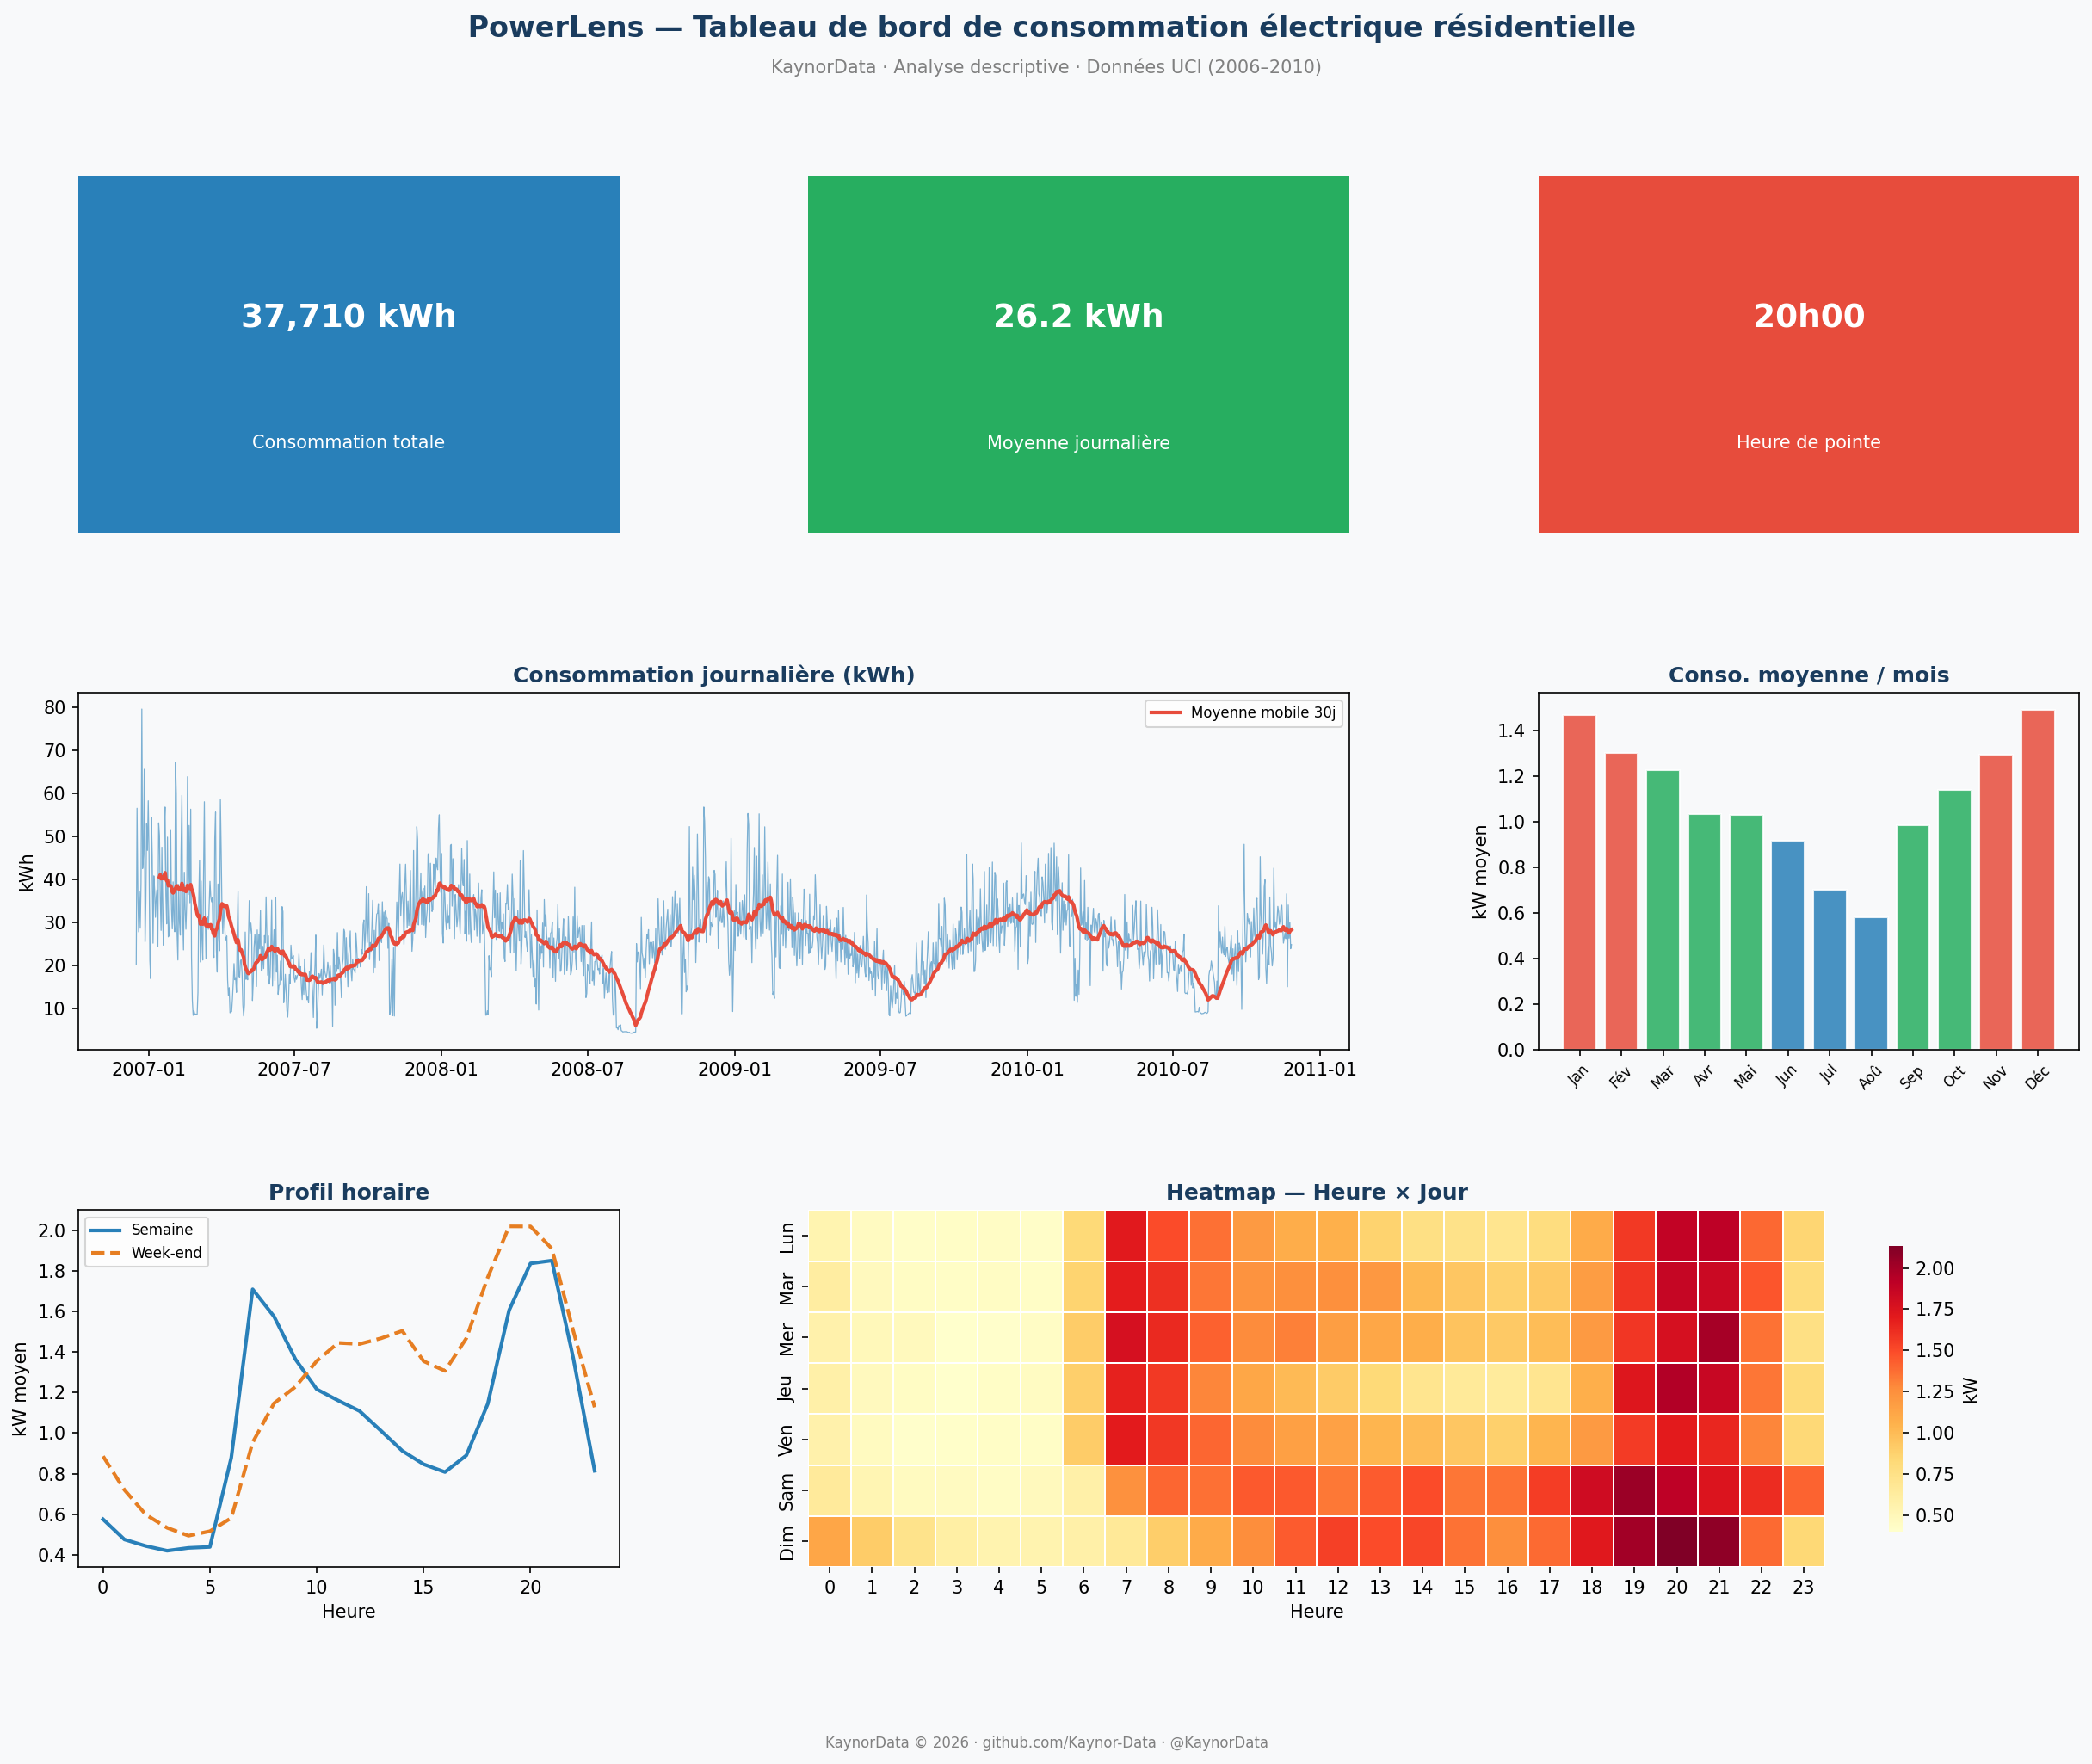

In [4]:
fig = plt.figure(figsize=(20, 14), facecolor=LIGHT_BG)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Titre principal ─────────────────────────────────────────────────────────
fig.text(0.5, 0.97, ' PowerLens — Tableau de bord de consommation électrique résidentielle',
         ha='center', va='top', fontsize=16, fontweight='bold', color=PRIMARY)
fig.text(0.5, 0.945, 'KaynorData · Analyse descriptive · Données UCI (2006–2010)',
         ha='center', va='top', fontsize=10, color='gray')

# ── KPI Cards (ligne 0, col 0-2) ─────────────────────────────────────────────
kpi_data = [
    (f'{total_kwh:,.0f} kWh',   'Consommation totale',  ACCENT),
    (f'{avg_daily_kwh:.1f} kWh','Moyenne journalière',  SUCCESS),
    (f'{peak_hour}h00',          'Heure de pointe',      DANGER),
]
for i, (val, label, color) in enumerate(kpi_data):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.6, val, ha='center', va='center', fontsize=18,
                fontweight='bold', color='white', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.25, label, ha='center', va='center', fontsize=10,
                color='white', transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values(): spine.set_visible(False)

# ── Graphique 1 : Tendance journalière (ligne 1, col 0-1) ───────────────────
ax1 = fig.add_subplot(gs[1, :2])
daily = df['energy_kwh'].resample('D').sum()
ax1.plot(daily.index, daily.values, color=ACCENT, linewidth=0.6, alpha=0.6)
ax1.plot(daily.rolling(30).mean().index, daily.rolling(30).mean().values,
         color=DANGER, linewidth=2, label='Moyenne mobile 30j')
ax1.set_title('Consommation journalière (kWh)', fontweight='bold', color=PRIMARY)
ax1.set_ylabel('kWh')
ax1.legend(fontsize=8)
ax1.set_facecolor(LIGHT_BG)

# ── Graphique 2 : Consommation par mois (ligne 1, col 2) ────────────────────
ax2 = fig.add_subplot(gs[1, 2])
monthly = df.groupby('month')['Global_active_power'].mean()
season_colors = [DANGER,DANGER,SUCCESS,SUCCESS,SUCCESS,ACCENT,ACCENT,ACCENT,SUCCESS,SUCCESS,DANGER,DANGER]
ax2.bar(list(month_names.values()), monthly.values, color=season_colors, alpha=0.85, edgecolor='white')
ax2.set_title('Conso. moyenne / mois', fontweight='bold', color=PRIMARY)
ax2.set_ylabel('kW moyen')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.set_facecolor(LIGHT_BG)

# ── Graphique 3 : Profil horaire semaine vs week-end (ligne 2, col 0) ───────
ax3 = fig.add_subplot(gs[2, 0])
wday = df[df['is_weekend']==0].groupby('hour')['Global_active_power'].mean()
wend = df[df['is_weekend']==1].groupby('hour')['Global_active_power'].mean()
ax3.plot(wday.index, wday.values, color=ACCENT, linewidth=2, label='Semaine')
ax3.plot(wend.index, wend.values, color=WARNING, linewidth=2, linestyle='--', label='Week-end')
ax3.set_title('Profil horaire', fontweight='bold', color=PRIMARY)
ax3.set_xlabel('Heure')
ax3.set_ylabel('kW moyen')
ax3.legend(fontsize=8)
ax3.set_facecolor(LIGHT_BG)

# ── Graphique 4 : Heatmap heure × jour (ligne 2, col 1-2) ───────────────────
ax4 = fig.add_subplot(gs[2, 1:])
pivot = df.groupby(['day_of_week','hour'])['Global_active_power'].mean().unstack()
pivot.index = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
sns.heatmap(pivot, cmap='YlOrRd', ax=ax4, linewidths=0.2,
            cbar_kws={'label':'kW', 'shrink':0.8})
ax4.set_title('Heatmap — Heure × Jour', fontweight='bold', color=PRIMARY)
ax4.set_xlabel('Heure')
ax4.set_ylabel('')

# ── Footer ───────────────────────────────────────────────────────────────────
fig.text(0.5, 0.01, 'KaynorData © 2026 · github.com/Kaynor-Data · @KaynorData',
         ha='center', fontsize=8, color='gray')

plt.savefig('../reports/figures/04_powerlens_dashboard.png', dpi=200, bbox_inches='tight',
            facecolor=LIGHT_BG)
print('Dashboard sauvegardé : reports/figures/04_powerlens_dashboard.png')
plt.show()

## 3. Export résumé CSV pour reporting

In [5]:
import os
os.makedirs('../reports', exist_ok=True)

# Résumé mensuel
monthly_report = df.resample('ME').agg(
    total_kwh=('energy_kwh', 'sum'),
    avg_power_kw=('Global_active_power', 'mean'),
    max_power_kw=('Global_active_power', 'max'),
    avg_voltage=('Voltage', 'mean')
).round(3)

monthly_report.to_csv('../reports/powerlens_monthly_report.csv')
print('Rapport mensuel sauvegardé : reports/powerlens_monthly_report.csv')
monthly_report.head(6)

Rapport mensuel sauvegardé : reports/powerlens_monthly_report.csv


,total_kwh,avg_power_kw,max_power_kw,avg_voltage
datetime,,,,
2006-12-31,697.113,1.902,9.132,241.441
2007-01-31,1150.288,1.546,9.272,240.905
2007-02-28,941.614,1.401,9.410,240.519
2007-03-31,981.045,1.319,10.670,240.514
2007-04-30,608.820,0.846,8.160,239.056
2007-05-31,733.481,0.986,7.672,235.178


## 4. Conclusions finales — PowerLens

### Ce que les données nous disent

| Insight | Détail | Impact |
|---------|--------|--------|
| **Pic vespéral** | 17h–21h = période de plus forte consommation | Gestion de charge critique pour les distributeurs |
| **Saisonnalité marquée** | Janvier–Février 2× plus élevé qu'en été | Planification des capacités réseau |
| **Profil week-end décalé** | Pic à 10h–11h vs 7h–8h en semaine | Tarification différenciée possible |
| **Sub-metering 3 dominant** | Chauffe-eau/climatisation = plus grand sous-compteur | Cible prioritaire pour programmes d'efficacité |
| **Corrélation parfaite** | Active Power ↔ Intensity (r ≈ 1.0) | Cohérence mesures électriques |

---

### Perspectives

- **WattScope** : Aller plus loin — détecter les anomalies et comprendre *pourquoi* certains pics se produisent
- **GridPulse** : Simuler la facturation et modéliser les coûts selon différentes grilles tarifaires
- **EnergyFlow** : Comparer avec d'autres foyers ou régions pour benchmarker

---
*Projet réalisé par **Beh Konaté** · KaynorData · 2026*